<a href="https://colab.research.google.com/github/FilledVaccum/Courses/blob/default-main/CampusX/100_days_of_ML/Day_25_Normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is Normalization?

Normalization is a data preprocessing technique used in machine learning to rescale numeric features to a standard range. This ensures that features with different scales (e.g., age and income) contribute equally to the model's learning process.

Why is Normalization Important?

    Improved Model Performance: Normalization can help algorithms converge faster and improve the accuracy of models, especially those sensitive to feature scales like distance-based algorithms (k-Nearest Neighbors, Support Vector Machines) and gradient descent-based algorithms.
    Reduced Bias: When features have different scales, features with larger values might disproportionately influence the model, leading to biased results. Normalization mitigates this issue by bringing all features to a similar range.
    Better Generalization: Normalization can improve the model's ability to generalize to unseen data by reducing the impact of outliers and ensuring that the model is not overly sensitive to the specific range of values in the training data.

Common Normalization Techniques

  Min-Max Scaling: This technique scales features to a specific range, typically between 0 and 1.

    import pandas as pd
    from sklearn.preprocessing import MinMaxScaler

    # Assuming 'data' is your pandas DataFrame with the features to be normalized
    scaler = MinMaxScaler()
    data['normalized_feature'] = scaler.fit_transform(data[['original_feature']])

Use code with caution

  Z-score Standardization: This technique transforms features to have zero mean and unit variance.

    import pandas as pd
    from sklearn.preprocessing import StandardScaler

    # Assuming 'data' is your pandas DataFrame with the features to be normalized
    scaler = StandardScaler()
    data['normalized_feature'] = scaler.fit_transform(data[['original_feature']])

When to Use Normalization

Normalization is generally recommended when your dataset has features with varying ranges and you are using algorithms sensitive to feature scales. However, it might not be necessary for all algorithms, and in some cases, it could even negatively impact performance. Experimentation and understanding the specific algorithm's requirements are crucial to determine whether normalization is beneficial.

# The differences between standardization and normalization in machine learning:

Both standardization and normalization are data preprocessing techniques used to rescale numeric features, but they differ in their approach and the resulting data distribution:

Normalization:

    Goal: To rescale features to a specific range, typically between 0 and 1.
    Method: Min-Max scaling is a common normalization technique. It involves subtracting the minimum value of the feature and dividing by the range (maximum value - minimum value).
    Effect: All feature values are transformed to a common scale within the specified range.
    When to Use: Useful when the data distribution is not known or is not Gaussian (normally distributed). It is also helpful for algorithms that require features to be within a specific range, like neural networks.

Standardization:

    Goal: To transform features to have zero mean and unit variance.
    Method: Z-score normalization is a common standardization technique. It involves subtracting the mean of the feature from each data point and dividing by the standard deviation.
    Effect: The data is centered around zero and scaled to have a standard deviation of 1.
    When to Use: Preferred when the data distribution is Gaussian or when using algorithms sensitive to feature scales, such as distance-based algorithms (k-Nearest Neighbors, Support Vector Machines) and gradient descent-based algorithms.

Here's a table summarizing the key differences:
Feature 	Normalization 	Standardization
Goal 	Rescale to a specific range (e.g., 0-1) 	Transform to zero mean and unit variance
Method 	Min-Max scaling 	Z-score normalization
Effect 	Features scaled to a common range 	Data centered and scaled
When to Use 	Data distribution unknown, algorithms requiring specific range 	Gaussian distribution, algorithms sensitive to feature scales

In essence:

    Normalization is about bringing all features to a similar scale within a specific range.
    Standardization is about transforming features to have a standard normal distribution.

Choosing between normalization and standardization depends on the specific dataset, algorithm, and the desired outcome. Experimentation and understanding the characteristics of your data and model are crucial for making the right choice. Let me know if you need help with a specific use case!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

This line uses the pandas library to read data from a CSV (Comma-Separated Values) file and create a DataFrame named df. Here's a step-by-step explanation:

    import pandas as pd: Before you can work with pandas, you need to import it. This line imports the pandas library and gives it a shorter alias pd for easier use throughout the code.

    df = ...: This part assigns the result of the operation to a variable named df. In pandas, a DataFrame is a two-dimensional table-like structure used to store and manipulate data. So, df will hold the data read from the CSV file.

    pd.read_csv(...): This is the core function call that reads the CSV file. Inside the parentheses are arguments that control how the file is read:
        'wine_data.csv': This is the name of the CSV file that you want to read data from. It's assumed to be in the same directory as your Python script or Jupyter Notebook.
        header = None: This argument tells pandas that the CSV file does not have a header row. A header row usually contains column names. By setting it to None, pandas will automatically assign numerical indices (0, 1, 2, etc.) as column names.
        usecols = [0,1,2]: This argument specifies which columns to read from the CSV file. In this case, it's reading only the first three columns (indexed 0, 1, and 2).

In simpler terms:

This line of code is like saying:

"Hey pandas, please read the file named 'wine_data.csv'. This file doesn't have column names in the first row, so don't look for them. Also, I only want the data from the first three columns. Store all this data in a table called df so I can work with it."


In [5]:
df = pd.read_csv('wine_data.csv', header = None, usecols = [0,1,13])
df.columns=['Alcohol', 'Malic acid', 'Class label']

In [6]:
df

,Alcohol,Malic acid,Class label
0,14.23,1.71,1
1,13.20,1.78,1
2,13.16,2.36,1
3,14.37,1.95,1
4,13.24,2.59,1
...,...,...,...
173,13.71,5.65,3
174,13.40,3.91,3
175,13.27,4.28,3
176,13.17,2.59,3


These lines use the seaborn library (sns) to create Kernel Density Estimation (KDE) plots.

    sns.kdeplot(df['Alcohol']):
        sns.kdeplot() is the function from seaborn used to generate a KDE plot.
        df['Alcohol'] selects the 'Alcohol' column from the df DataFrame. This column contains the alcohol content data for the wines.
        This line essentially creates a KDE plot visualizing the distribution of the 'Alcohol' data. The plot shows the density of data points across different alcohol content values, giving you an idea of the shape of the distribution.

    sns.kdeplot(df['Malic acid']):
        This line is very similar to the first but focuses on the 'Malic acid' column.
        It generates a KDE plot to visualize the distribution of malic acid content in the wines.

In summary, these two lines of code create two separate KDE plots, one for the 'Alcohol' data and one for the 'Malic acid' data, allowing you to visually compare their distributions within the dataset. This helps to understand the spread and concentration of these two features in the wine data.


<Axes: xlabel='Alcohol', ylabel='Density'>

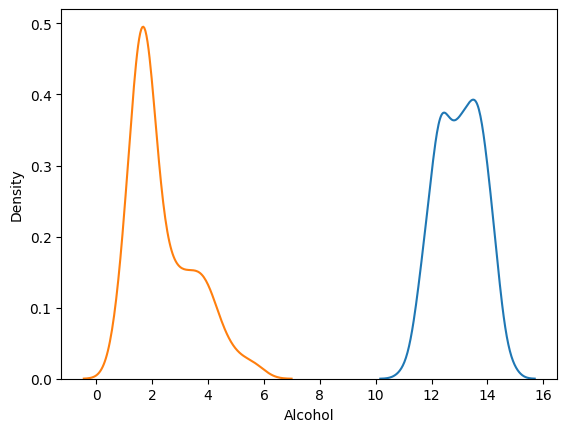

In [8]:
sns.kdeplot(df['Alcohol'])
sns.kdeplot(df['Malic acid'])

What is a Kernel Density Estimation (KDE) Plot?

A KDE plot is a method for visualizing the distribution of observations in a dataset, analogous to a histogram. Instead of using discrete bins like a histogram, KDE plots represent the data using a continuous probability density curve. This curve is estimated using a technique called Kernel Density Estimation.

How KDE Works

    Kernels: KDE starts by placing a kernel, which is a smooth, symmetric function (like a Gaussian bell curve), at each data point.

    Bandwidth: The bandwidth (h) is a crucial parameter that determines the width of the kernel. A smaller bandwidth produces a more detailed plot, highlighting local variations in the data, while a larger bandwidth results in a smoother curve, emphasizing the overall distribution shape.

    Summation: The kernels placed at each data point are then summed to create the overall density estimate. The height of the curve at any given point represents the estimated probability density of observing a data point at that location.

Advantages of KDE Plots

    Continuous Representation: KDE plots provide a continuous and smooth representation of the data distribution, unlike histograms, which can be sensitive to bin size and placement.
    Better Visualization: KDE plots can be more visually appealing and easier to interpret than histograms, especially when dealing with multiple distributions.
    Outlier Detection: KDE plots can help identify potential outliers, which appear as isolated peaks or bumps in the density curve.
    Flexibility: KDE plots can be easily customized by adjusting the kernel and bandwidth parameters.

Disadvantages of KDE Plots

    Bandwidth Selection: Choosing the optimal bandwidth is crucial but can be subjective. Different bandwidths can significantly alter the appearance of the plot.
    Computational Cost: KDE can be computationally intensive, especially for large datasets.
    Boundary Bias: KDE can underestimate the density near the boundaries of the data range.

When to Use KDE Plots

KDE plots are particularly useful in the following scenarios:

    Visualizing Data Distributions: When you want to understand the shape, spread, and modality (number of peaks) of a dataset.
    Comparing Distributions: When you need to compare the distributions of different groups or variables.
    Exploring Data Patterns: When you are looking for clusters, gaps, or other interesting patterns in the data.

Interpreting a KDE Plot

    X-axis: Represents the values of the variable being plotted.
    Y-axis: Represents the estimated probability density. Higher values indicate a greater concentration of data points.
    Peaks: Indicate areas of high data density, potentially representing modes or clusters in the data.
    Valleys: Indicate areas of low data density, potentially representing gaps or separations between groups.
    Shape: The overall shape of the curve can provide insights into the underlying distribution of the data (e.g., symmetric, skewed, multimodal).

In the context of the original code:

sns.kdeplot(df['Alcohol'])
sns.kdeplot(df['Malic acid'])

Use code with caution

These lines generate two KDE plots, one for the "Alcohol" variable and one for the "Malic acid" variable. This allows us to visually compare the distributions of these two features in the wine dataset, giving us an idea of their typical ranges, central tendencies, and any potential outliers. The shape of the curves can also suggest whether these variables follow a normal distribution or some other pattern.

# Explaining The Code

    Creating a Color Dictionary:
        color_dict = {1 : 'red', 2 : 'green', 3 : 'blue'}: This line creates a Python dictionary called color_dict.
        This dictionary is used to map specific values to colors. In this case:
            The value 1 will be represented by the color 'red'.
            The value 2 will be represented by the color 'green'.
            The value 3 will be represented by the color 'blue'.

    Creating the Scatter Plot:
        sns.scatterplot(...): This line uses the seaborn library (sns) to create a scatter plot. Let's look at the arguments:
            data = df: This specifies that the data for the plot comes from the pandas DataFrame df.
            x = 'Alcohol': This sets the 'Alcohol' column from df as the data for the x-axis.
            y = 'Malic acid': This sets the 'Malic acid' column from df as the data for the y-axis.
            hue = df['Class label']: This tells the plot to color the points based on the 'Class label' column in df. Different 'Class label' values will get different colors.
            palette = color_dict: This is where the color_dict we created earlier comes in. It tells the scatterplot function to use the color mappings defined in color_dict for the 'Class label' values.

In Summary:

This code creates a scatter plot where:

    The x-axis represents 'Alcohol' values.
    The y-axis represents 'Malic acid' values.
    Points are colored based on their 'Class label' using the colors defined in color_dict. This means that points with 'Class label' 1 will be red, those with 'Class label' 2 will be green, and those with 'Class label' 3 will be blue.



<Axes: xlabel='Alcohol', ylabel='Malic acid'>

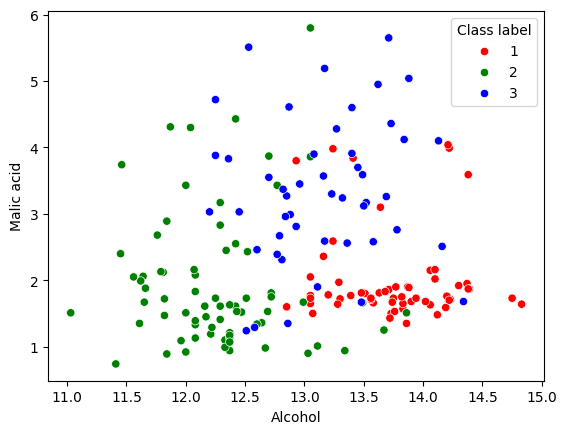

In [10]:
color_dict ={
    1 : 'red',
    2 : 'green',
    3 : 'blue'
}

sns.scatterplot(data = df, x = 'Alcohol', y = 'Malic acid', hue = df['Class label'], palette = color_dict)

### Train Test Split

# Explaining the code
This code is used to prepare data for training a machine learning model. It essentially splits the data into two sets: one for training the model (X_train, y_train) and one for testing its performance (X_test, y_test).

Here's a step-by-step explanation:

    from sklearn.model_selection import train_test_split: This line imports the train_test_split function from the sklearn.model_selection module. This function is a key tool for splitting datasets.

    X_train, X_test, y_train, y_test = train_test_split(...): This line calls the train_test_split function and assigns the results to four variables:
        X_train: This will store the features (input data) for training the model.
        X_test: This will store the features for testing the trained model.
        y_train: This will store the target variable (what the model is trying to predict) corresponding to the training data.
        y_test: This will store the target variable corresponding to the testing data.

    df.drop('Class Label', axis = 1 ): This part of the code selects the features from the DataFrame df by dropping the 'Class Label' column. The axis=1 argument indicates that we are dropping a column. This is passed as the first argument to train_test_split, indicating the data containing the features.

    df['Class label']: This part selects the 'Class label' column from the DataFrame df, which represents the target variable. It is passed as the second argument to train_test_split.

    test_size = 0.3: This parameter specifies the proportion of the dataset to include in the test split. In this case, 30% of the data will be used for testing, and the remaining 70% for training.

    random_state = 0: This parameter ensures that the data is split in a reproducible way. By setting a specific value (here, 0), you guarantee that the same split will be obtained every time you run the code with the same data. This is important for comparing results across different runs.

In essence, this code snippet takes a dataset (df), separates the features from the target variable, and then splits the data into training and testing sets, ensuring reproducibility using random_state. This is a crucial step before training a machine learning model, allowing you to evaluate its performance on unseen data.


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis = 1 ), df['Class label'], test_size = 0.3, random_state = 0)

In [16]:
X_train.shape, X_test.shape

((124, 2), (54, 2))

# MinMaxScaler

## Difference Between Fit and Transform
fit:

    Purpose: The fit method is used to calculate and store the necessary parameters for the scaling operation. In the case of MinMaxScaler, this involves finding the minimum and maximum values of each feature in the training data.
    Input: It takes the training data as input (X_train in the example).
    Output: It doesn't directly return transformed data. Instead, it modifies the scaler object itself by storing the calculated parameters (min and max values).
    When it's used: It's applied only once to the training data to prepare the scaling transformation.

transform:

    Purpose: The transform method applies the scaling transformation to a dataset using the parameters that were previously learned during the fit step. It actually rescales the data.
    Input: It takes the dataset you want to scale as input (e.g., X_train or X_test).
    Output: It returns the transformed dataset where features have been rescaled according to the fitted parameters.
    When it's used: It's applied to both the training data and any new data you want to use with the model (like the test data or validation data).

Why the distinction matters:

    Avoiding data leakage: We only fit on the training data to prevent information from the test data from influencing the scaling process. If we were to fit on the entire dataset, the model might inadvertently learn something about the test data, leading to overly optimistic performance estimates.
    Consistent scaling: By using the same parameters (learned from the training data) to transform both the training and test data, we ensure that they are scaled in a consistent manner. This is crucial for the model to make accurate predictions on unseen data.

fit_transform

Many preprocessing tools in scikit-learn, including MinMaxScaler, also provide a fit_transform method. This method combines the fit and transform steps into a single operation. This can be more convenient for the training data, but remember to only use transform on the test set.

# Explaning the code
This code snippet is performing Min-Max scaling on the training and test data (X_train and X_test). Here's a step-by-step explanation:

    Import MinMaxScaler:

from sklearn.preprocessing import MinMaxScaler

Use code with caution

This line imports the MinMaxScaler tool from the sklearn.preprocessing module. This tool is used to perform Min-Max scaling.

    Create a Scaler Object:

scaler = MinMaxScaler()

Use code with caution

This line creates an instance of the MinMaxScaler and assigns it to the variable scaler. This object will be used to scale the data.

    Fit the Scaler to Training Data:

scaler.fit(X_train)

Use code with caution

This line is crucial. It calculates the minimum and maximum values of each feature in the training dataset (X_train). The scaler object now stores these values internally. It's important to only fit the scaler on the training data to avoid data leakage from the test set.

    Transform Training and Test Data:

X_train_scaled = scaler.transform(X_train)
   X_test_scaled = scaler.transform(X_test)

Use code with caution

These lines apply the scaling transformation to both the training data (X_train) and the test data (X_test). It uses the minimum and maximum values previously calculated during the fit step to rescale the features of both datasets to a range between 0 and 1.

In summary: This code takes your training and test data, finds the minimum and maximum values of each feature in the training data, and then scales both the training and test data based on those values, ensuring that all features are within the range of 0 to 1. This helps to ensure that features with different scales are treated equally by machine learning models.


In [17]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Let's break down these two lines of code:

X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

Use code with caution

These lines are converting the scaled data back into Pandas DataFrames. Here's a step-by-step explanation:

    X_train_scaled and X_test_scaled before these lines:
        These variables hold the output of the scaler.transform() function.
        The output of scaler.transform() is a NumPy array. This array contains the scaled values of your features but it's not a DataFrame anymore.
    pd.DataFrame(...):
        This is using the Pandas library (pd) to create a new DataFrame.
    X_train_scaled = ... and X_test_scaled = ...:
        The newly created DataFrames are assigned back to the X_train_scaled and X_test_scaled variables, effectively overwriting the NumPy arrays.
    columns = X_train.columns and columns = X_test.columns:
        This part is crucial. It's ensuring that the new DataFrames have the same column names as the original X_train and X_test DataFrames. This makes it easier to work with the data after scaling because you can still refer to the features by their original names.

In summary:

These lines are taking the scaled data (which is in NumPy array format) and putting it back into a familiar Pandas DataFrame format with the original column names. This makes the scaled data easier to manage and use for further analysis or model training.
[link text](https://)

In [18]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

'''
This code snippet is used to display a statistical summary of the X_train DataFrame, rounded to one decimal place. Here's how it works:

    X_train.describe(): This part calls the describe() method on the X_train DataFrame, which is a Pandas DataFrame likely containing numerical features used for training a machine learning model. The describe() method calculates descriptive statistics like count, mean, standard deviation, minimum, maximum, and quartiles for each numerical column in the DataFrame.

    np.round(..., 1): This part uses the round() function from the NumPy library (np). It takes two arguments:
        The first argument is the result of X_train.describe(), which is a Pandas DataFrame containing the descriptive statistics.
        The second argument, 1, specifies the number of decimal places to round the values to.

In simpler terms:

Imagine you have a table of data with columns like "Age" and "Income". X_train.describe() calculates things like the average age, the highest income, etc. for that table. np.round(..., 1) then takes those calculated values and rounds them off to one decimal place to make them easier to read.

Therefore, this line of code essentially generates a concise statistical overview of the training data (X_train), with all values rounded to one decimal place for better readability.
'''

In [29]:
np.round(X_train.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [21]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


This code is creating a figure with two scatter plots side-by-side to compare the data before and after scaling. Here's a detailed explanation:

    fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12,5)):
        This line creates a figure (fig) and two subplots (ax1, ax2) using the matplotlib.pyplot.subplots function.
        ncols = 2 specifies that we want two plots arranged in columns.
        figsize = (12,5) sets the width and height of the figure in inches.

    ax1.scatter(X_train['Alcohol'], X_train['Malic acid'], c = y_train):
        This line creates a scatter plot on the first subplot (ax1).
        X_train['Alcohol'] provides the x-coordinates (Alcohol values).
        X_train['Malic acid'] provides the y-coordinates (Malic acid values).
        c = y_train uses the y_train variable to color the points based on their class labels. This helps visualize how the different classes are distributed in the feature space.

    ax1.set_title('Before Scaling'):
        This line sets the title of the first subplot to "Before Scaling".

    ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c = y_train):
        This line creates a scatter plot on the second subplot (ax2), similar to the first one.
        The key difference is that it uses the scaled data (X_train_scaled) instead of the original data. This shows the effect of scaling on the data distribution.

    ax2.set_title('After Scaling'):
        This line sets the title of the second subplot to "After Scaling".

    plt.show():
        This line displays the entire figure with both subplots.

In essence, this code is visualizing the effect of scaling on the 'Alcohol' and 'Malic acid' features of the wine dataset. By comparing the two scatter plots, you can see how the data points are distributed before and after the scaling process.


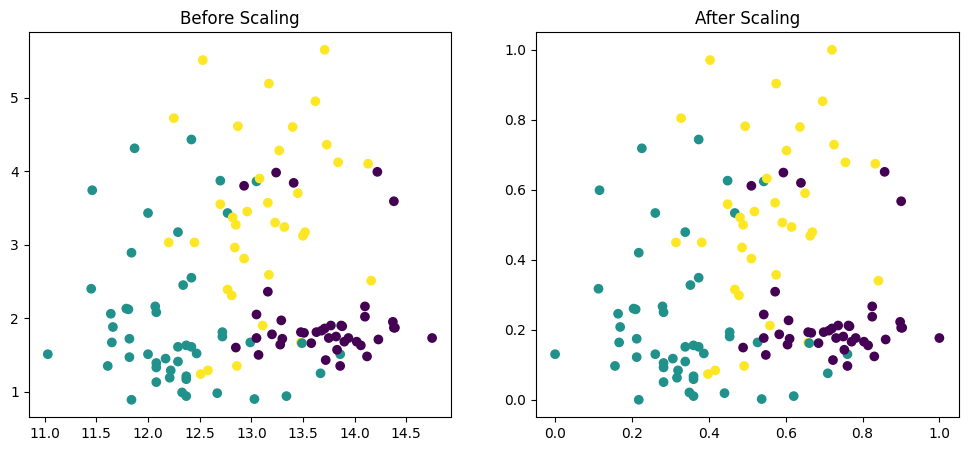

In [25]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12,5))
ax1.scatter(X_train['Alcohol'], X_train['Malic acid'], c = y_train)
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c = y_train)
ax2.set_title('After Scaling')
plt.show()

This code creates a figure with two subplots to visualize the distributions of the Alcohol and Malic acid features before and after scaling using kernel density estimation (KDE) plots.

fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

Use code with caution

    fig, (ax1, ax2) = plt.subplots(...): This line creates the overall figure (fig) and two subplots (ax1, ax2) side-by-side (ncols = 2). figsize = (12, 5) sets the dimensions of the figure.

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Alcohol'], ax = ax1)
sns.kdeplot(X_train['Malic acid'], ax = ax1)

Use code with caution

    Before Scaling: This section focuses on the first subplot (ax1).
    ax1.set_title("Before Scaling"): Sets the title of the first subplot.
    sns.kdeplot(X_train['Alcohol'], ax = ax1): This creates a KDE plot for the Alcohol feature from the original X_train data and places it on ax1. KDE plots show the probability density of the data.
    sns.kdeplot(X_train['Malic acid'], ax = ax1): Similarly, this creates a KDE plot for the Malic acid feature from the original X_train data and overlays it on the same subplot (ax1).

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled['Alcohol'], ax = ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax = ax2)

Use code with caution

    After Scaling: This section focuses on the second subplot (ax2).
    ax2.set_title("After Scaling"): Sets the title of the second subplot.
    sns.kdeplot(X_train_scaled['Alcohol'], ax = ax2): This creates a KDE plot for the scaled Alcohol feature from X_train_scaled and places it on ax2.
    sns.kdeplot(X_train_scaled['Malic acid'], ax = ax2): Similarly, this creates a KDE plot for the scaled Malic acid feature and overlays it on ax2.

plt.show()

Use code with caution

    plt.show(): This line finally displays the entire figure with both subplots, allowing you to compare the distributions of the features before and after scaling.

In summary, this code visually compares the distributions of the 'Alcohol' and 'Malic acid' features in the wine dataset before and after they have been scaled using MinMaxScaler. This helps in understanding the effect of scaling on the data's distribution and range.


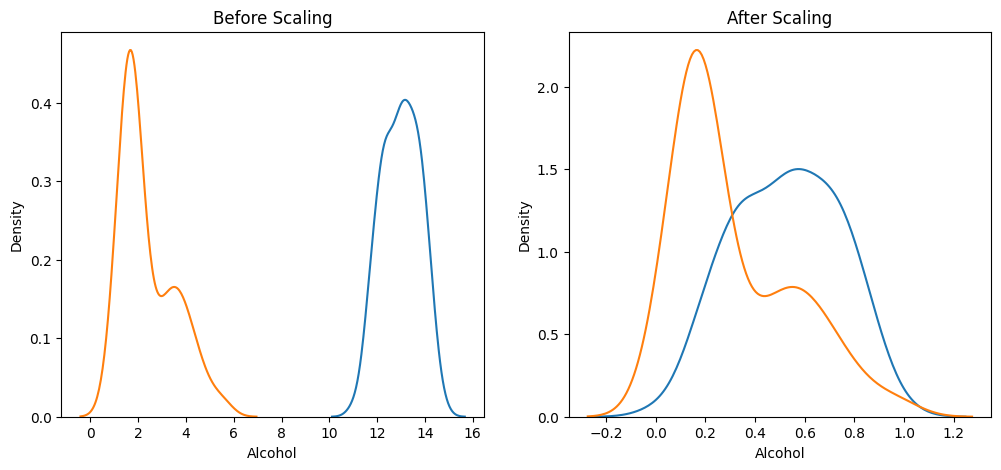

In [28]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Alcohol'], ax = ax1)
sns.kdeplot(X_train['Malic acid'], ax = ax1)

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled['Alcohol'], ax = ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax = ax2)

plt.show()

let's address why KDE plots can sometimes show negative values, even when the original data doesn't have any.

The Reason:

Kernel Density Estimation (KDE) is a method for estimating the probability density function (PDF) of a continuous random variable. It works by placing a kernel (a smooth, symmetric function) at each data point and summing these kernels to create a smooth curve that represents the data's distribution.

Gaussian Kernels and Negative Values:

The most common kernel used in KDE is the Gaussian kernel (a normal distribution curve). Gaussian kernels have infinite support, meaning they extend infinitely in both positive and negative directions.

Why this matters:

    Extrapolation: Even if your data only contains positive values, the Gaussian kernels placed at data points near zero will extend slightly into the negative range. When these kernels are summed, it can result in the KDE curve having non-zero density values for negative values.

    Smoothness: The primary goal of KDE is to provide a smooth estimate of the data's distribution. If the KDE curve was forced to be zero for negative values, it would create a sharp discontinuity, making the estimate less smooth.

In Practice:

While KDE plots might show negative values, the density assigned to these negative values is usually very small. This means that the KDE is essentially saying there's a very low probability of observing a negative value, which is reasonable given the nature of many real-world datasets.

Should you worry?

In most cases, the negative values in a KDE plot are not a major concern, especially if they are close to zero and the majority of the density is concentrated in the positive range.

How to handle it:

If you absolutely need to avoid negative values in your visualizations, you can:

    Limit the x-axis: Set the x-axis limits to start at zero or a slightly positive value to visually focus on the relevant range of the data.
    Consider alternative visualizations: If the presence of negative values is causing significant interpretation issues, you could explore other visualization methods like histograms with appropriate binning.

In the context of your wine data:

The negative values in the KDE plots are likely a result of the Gaussian kernels extending slightly into the negative range. Since the density values associated with these negative values are probably very small, it's generally safe to interpret the KDE plot while focusing on the positive values.